## Soil Nutrient Dataset PCA Pipeline

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### Step 1: Data Preparation

Load the CSV, check for missing values, and separate the numeric nutrient features from the Sample_ID/Zone identifier columns.

In [ ]:
# Load the dataset
try:
    df = pd.read_csv('soil_nutrient_dataset.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'soil_nutrient_dataset.csv' not found. Please upload the file.")
    # Create a dummy dataframe for demonstration if file is not found
    data = {
        'Sample_ID': range(1, 501),
        'Zone': np.random.choice([f'Zone_{i}' for i in range(1, 11)], 500),
        'N_kg_per_ha': np.random.rand(500) * 100 + 50,
        'P_kg_per_ha': np.random.rand(500) * 50 + 20,
        'K_kg_per_ha': np.random.rand(500) * 80 + 30,
        'pH': np.random.rand(500) * 2 + 5.5,
        'Organic_Carbon_pct': np.random.rand(500) * 5 + 1,
        'EC_dS_per_m': np.random.rand(500) * 1 + 0.5,
        'Fe_ppm': np.random.rand(500) * 100 + 20,
        'Zn_ppm': np.random.rand(500) * 20 + 5,
        'Mn_ppm': np.random.rand(500) * 50 + 10,
        'Cu_ppm': np.random.rand(500) * 10 + 1
    }
    df = pd.DataFrame(data)
    print("Dummy dataset created for demonstration purposes.")

display(df.head())

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Separate identifier columns from numeric features
identifier_cols = ['Sample_ID', 'Zone']
numeric_features = df.drop(columns=identifier_cols)

print("\nNumeric features ready for standardization:")
display(numeric_features.head())

Dataset loaded successfully.


,Sample_ID,Zone,N_kg_per_ha,P_kg_per_ha,K_kg_per_ha,pH,Organic_Carbon_pct,EC_dS_per_m,Fe_ppm,Zn_ppm,Mn_ppm,Cu_ppm
0,S0001,Zone_1,340.28,22.26,223.15,7.57,0.57,0.23,16.36,0.87,7.15,0.82
1,S0002,Zone_1,374.76,34.66,248.93,7.62,0.94,0.30,19.49,1.01,9.56,1.08
2,S0003,Zone_1,310.91,20.85,224.00,7.02,0.67,0.33,23.31,1.60,11.50,1.56
3,S0004,Zone_1,450.50,37.06,260.21,6.31,1.17,0.55,24.82,1.53,10.34,1.51
4,S0005,Zone_1,366.60,32.66,221.76,7.01,0.89,0.41,24.76,1.73,12.25,1.54



Missing values per column:


,0
Sample_ID,0
Zone,0
N_kg_per_ha,0
P_kg_per_ha,0
K_kg_per_ha,0
pH,0
Organic_Carbon_pct,0
EC_dS_per_m,0
Fe_ppm,0
Zn_ppm,0



Numeric features ready for standardization:


,N_kg_per_ha,P_kg_per_ha,K_kg_per_ha,pH,Organic_Carbon_pct,EC_dS_per_m,Fe_ppm,Zn_ppm,Mn_ppm,Cu_ppm
0,340.28,22.26,223.15,7.57,0.57,0.23,16.36,0.87,7.15,0.82
1,374.76,34.66,248.93,7.62,0.94,0.30,19.49,1.01,9.56,1.08
2,310.91,20.85,224.00,7.02,0.67,0.33,23.31,1.60,11.50,1.56
3,450.50,37.06,260.21,6.31,1.17,0.55,24.82,1.53,10.34,1.51
4,366.60,32.66,221.76,7.01,0.89,0.41,24.76,1.73,12.25,1.54


### Step 2: Standardization

Apply Z-score standardization (StandardScaler) to the numeric features so units like ppm, %, and pH are comparable.

In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to numeric features
scaled_features = scaler.fit_transform(numeric_features)

# Convert scaled features back to a DataFrame for easier handling
df_scaled = pd.DataFrame(scaled_features, columns=numeric_features.columns)

print("Standardized numeric features:")
display(df_scaled.head())

# Add Sample_ID and Zone back to the scaled DataFrame for later use
df_scaled[identifier_cols] = df[identifier_cols]


Standardized numeric features:


,N_kg_per_ha,P_kg_per_ha,K_kg_per_ha,pH,Organic_Carbon_pct,EC_dS_per_m,Fe_ppm,Zn_ppm,Mn_ppm,Cu_ppm
0,1.105742,0.244899,0.906921,1.207311,-0.080836,-1.218927,-0.066344,-0.491615,-0.255214,-0.433610
1,1.549439,1.651324,1.310457,1.274665,1.532237,-0.885878,0.360164,-0.230539,0.454115,0.090498
2,0.727801,0.084975,0.920226,0.466424,0.355130,-0.743143,0.880694,0.869710,1.025109,1.058081
3,2.524080,1.923535,1.487023,-0.489993,2.534957,0.303583,1.086454,0.739172,0.683690,0.957291
4,1.444434,1.424481,0.885163,0.452954,1.314254,-0.362515,1.078278,1.112137,1.245855,1.017765


### Step 3: Covariance/Correlation Matrix

Compute and visualize the covariance/correlation matrix as a heatmap to show inter-variable dependencies among macro- and micro-nutrients.

Correlation Matrix:


,N_kg_per_ha,P_kg_per_ha,K_kg_per_ha,pH,Organic_Carbon_pct,EC_dS_per_m,Fe_ppm,Zn_ppm,Mn_ppm,Cu_ppm
N_kg_per_ha,1.000000,0.828279,0.754171,0.118453,0.867515,-0.229589,0.363369,0.313168,0.334804,0.284451
P_kg_per_ha,0.828279,1.000000,0.761037,0.082397,0.784432,-0.113644,0.269872,0.283470,0.254024,0.204616
K_kg_per_ha,0.754171,0.761037,1.000000,0.186036,0.688651,-0.108776,0.274794,0.277167,0.276523,0.239988
pH,0.118453,0.082397,0.186036,1.000000,0.047672,0.103540,-0.274137,-0.284328,-0.316047,-0.193178
Organic_Carbon_pct,0.867515,0.784432,0.688651,0.047672,1.000000,-0.118890,0.352846,0.325728,0.340485,0.262210
EC_dS_per_m,-0.229589,-0.113644,-0.108776,0.103540,-0.118890,1.000000,-0.284813,-0.269639,-0.292732,-0.260370
Fe_ppm,0.363369,0.269872,0.274794,-0.274137,0.352846,-0.284813,1.000000,0.811338,0.826548,0.761844
Zn_ppm,0.313168,0.283470,0.277167,-0.284328,0.325728,-0.269639,0.811338,1.000000,0.782544,0.763330
Mn_ppm,0.334804,0.254024,0.276523,-0.316047,0.340485,-0.292732,0.826548,0.782544,1.000000,0.733427
Cu_ppm,0.284451,0.204616,0.239988,-0.193178,0.262210,-0.260370,0.761844,0.763330,0.733427,1.000000


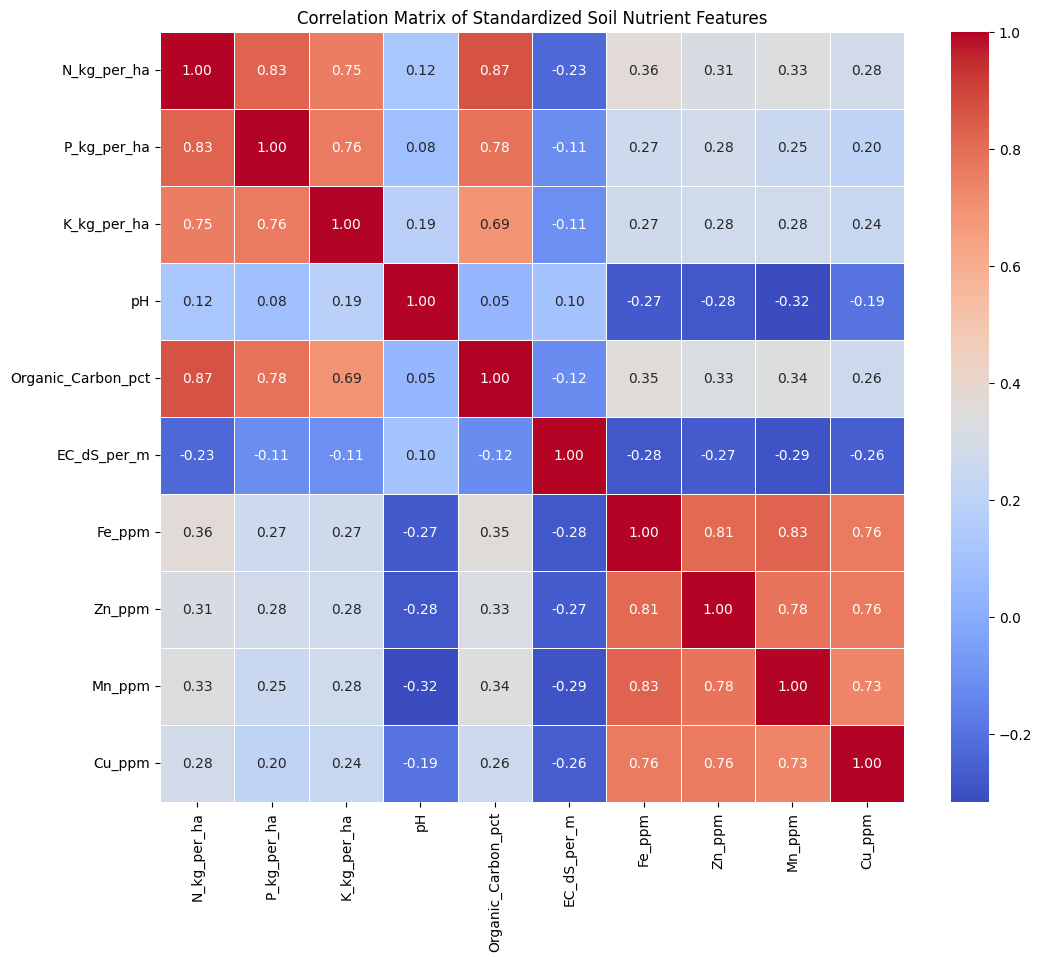

In [ ]:
# Calculate the correlation matrix on the standardized features
correlation_matrix = df_scaled.drop(columns=identifier_cols).corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Standardized Soil Nutrient Features')
plt.show()

### Step 4: PCA / Eigendecomposition

Fit `sklearn.decomposition.PCA` on the standardized data. Print the eigenvalues, explained variance ratio, and cumulative explained variance for each component.

In [ ]:
# Initialize PCA with all components (n_components=None)
pca = PCA(n_components=None)

# Fit PCA on the standardized data
pca.fit(df_scaled.drop(columns=identifier_cols))

# Get eigenvalues (variance of each principal component)
eigenvalues = pca.explained_variance_
print("Eigenvalues (Variance of each Principal Component):")
print(eigenvalues)

# Get explained variance ratio for each component
explained_variance_ratio = pca.explained_variance_ratio_
print("\nExplained Variance Ratio for each Principal Component:")
print(explained_variance_ratio)

# Get cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative Explained Variance:")
print(cumulative_explained_variance)

# Create a DataFrame for better display of results
pca_results = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Explained Variance Ratio': explained_variance_ratio,
    'Cumulative Explained Variance': cumulative_explained_variance
})

display(pca_results)

Eigenvalues (Variance of each Principal Component):
[4.63758881 2.40891492 0.8881444  0.81971815 0.32418047 0.26411295
 0.22744432 0.17744209 0.16675473 0.10573925]

Explained Variance Ratio for each Principal Component:
[0.46283136 0.24040971 0.08863681 0.08180787 0.03235321 0.02635847
 0.02269894 0.01770872 0.01664212 0.01055278]

Cumulative Explained Variance:
[0.46283136 0.70324107 0.79187788 0.87368575 0.90603896 0.93239744
 0.95509638 0.9728051  0.98944722 1.        ]


,Principal Component,Eigenvalue,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,4.637589,0.462831,0.462831
1,PC2,2.408915,0.240410,0.703241
2,PC3,0.888144,0.088637,0.791878
3,PC4,0.819718,0.081808,0.873686
4,PC5,0.324180,0.032353,0.906039
5,PC6,0.264113,0.026358,0.932397
6,PC7,0.227444,0.022699,0.955096
7,PC8,0.177442,0.017709,0.972805
8,PC9,0.166755,0.016642,0.989447
9,PC10,0.105739,0.010553,1.000000


### Step 5: Scree Plot

Plot explained variance ratio per component and cumulative variance, and mark how many components are needed to reach ~80–85% variance.

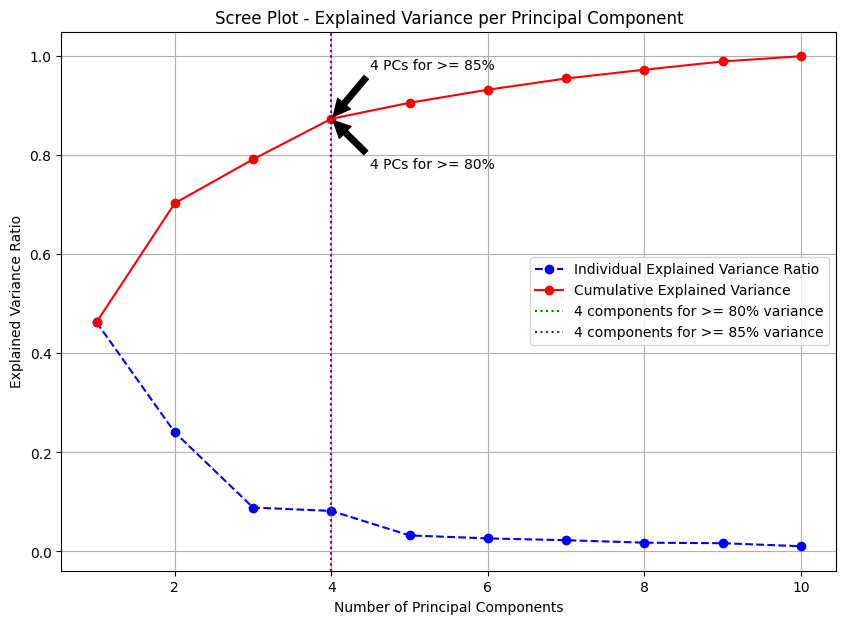

Number of components to explain >= 80% variance: 4
Number of components to explain >= 85% variance: 4


In [ ]:
plt.figure(figsize=(10, 7))

# Plot explained variance ratio
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='blue', label='Individual Explained Variance Ratio')

# Plot cumulative explained variance
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='red', label='Cumulative Explained Variance')

plt.title('Scree Plot - Explained Variance per Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.legend()

# Mark ~80-85% variance
# Find the number of components for 80% and 85% cumulative variance
components_80_percent = np.where(cumulative_explained_variance >= 0.80)[0][0] + 1
components_85_percent = np.where(cumulative_explained_variance >= 0.85)[0][0] + 1

plt.axvline(x=components_80_percent, color='green', linestyle=':', label=f'{components_80_percent} components for >= 80% variance')
plt.axvline(x=components_85_percent, color='purple', linestyle=':', label=f'{components_85_percent} components for >= 85% variance')

plt.annotate(f'{components_80_percent} PCs for >= 80%', xy=(components_80_percent, cumulative_explained_variance[components_80_percent-1]),
             xytext=(components_80_percent + 0.5, cumulative_explained_variance[components_80_percent-1] - 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate(f'{components_85_percent} PCs for >= 85%', xy=(components_85_percent, cumulative_explained_variance[components_85_percent-1]),
             xytext=(components_85_percent + 0.5, cumulative_explained_variance[components_85_percent-1] + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.legend()
plt.show()

print(f"Number of components to explain >= 80% variance: {components_80_percent}")
print(f"Number of components to explain >= 85% variance: {components_85_percent}")

### Step 6: 2D Biplot

Project the data onto PC1 and PC2, color points by Zone, and overlay the original feature loading vectors (arrows) to show which nutrients drive each component.

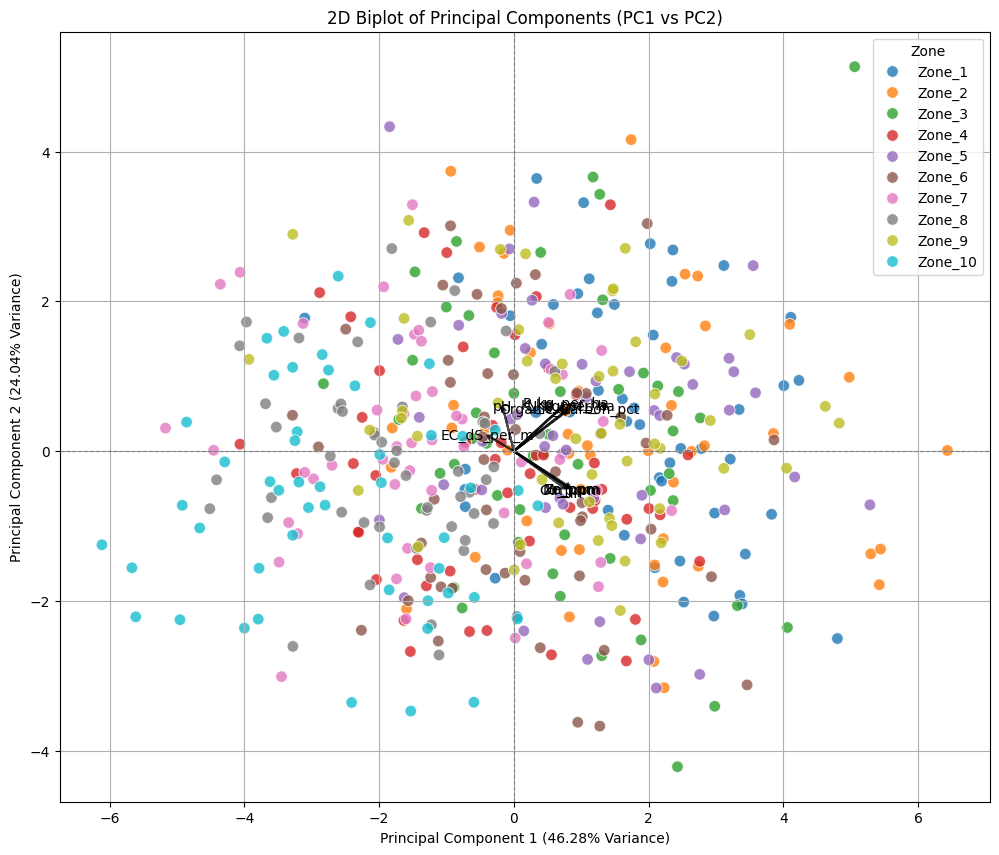

In [ ]:
# Project the standardized data onto the first two principal components
pca_components = pca.fit_transform(df_scaled.drop(columns=identifier_cols))
df_pca = pd.DataFrame(data=pca_components, columns=[f'PC{i+1}' for i in range(pca_components.shape[1])])

# Add the 'Zone' column back for coloring
df_pca['Zone'] = df['Zone']

plt.figure(figsize=(12, 10))

# Scatter plot of PC1 vs PC2, colored by Zone
sns.scatterplot(x='PC1', y='PC2', hue='Zone', data=df_pca, s=70, alpha=0.8)

# Get the loadings (eigenvectors) for the first two components
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Get feature names
feature_names = numeric_features.columns

# Plot loading vectors
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='black', alpha=0.7,
              head_width=0.05, head_length=0.05, lw=1.5)
    plt.text(loadings[i, 0] * 1.1, loadings[i, 1] * 1.1, feature, color='black', ha='center', va='center')

plt.title('2D Biplot of Principal Components (PC1 vs PC2)')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% Variance)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

### Step 7: 3D Biplot

Build an interactive 3D scatter plot (Plotly) of PC1, PC2, PC3, colored by Zone.

In [ ]:
# Ensure pca_components has at least 3 components for 3D biplot
if pca_components.shape[1] < 3:
    print("Not enough principal components to create a 3D biplot. At least 3 components are required.")
else:
    # Prepare data for 3D plot
    df_pca_3d = df_pca.copy()
    df_pca_3d['PC3'] = pca_components[:, 2]

    # Create interactive 3D scatter plot
    fig = px.scatter_3d(df_pca_3d, x='PC1', y='PC2', z='PC3', color='Zone',
                        title='3D Biplot of Principal Components (PC1, PC2, PC3)',
                        labels={'PC1': f'PC1 ({explained_variance_ratio[0]*100:.2f}%)',
                                'PC2': f'PC2 ({explained_variance_ratio[1]*100:.2f}%)',
                                'PC3': f'PC3 ({explained_variance_ratio[2]*100:.2f}%)'})

    # Add original feature loading vectors as cones/arrows to the 3D plot
    # For 3D, loadings should also be taken for PC3
    loadings_3d = pca.components_.T  # Loadings matrix (features x components)

    # Only consider the top 3 components for the 3D biplot arrows
    for i, feature in enumerate(feature_names):
        fig.add_trace(go.Cone(
            x=[0], y=[0], z=[0],
            u=[loadings_3d[i, 0]], v=[loadings_3d[i, 1]], w=[loadings_3d[i, 2]],
            sizemode="absolute", sizeref=0.1,  # Adjust sizeref to control arrow size
            anchor="tip", showscale=False,
            text=[feature],
            hoverinfo='text'
        ))
        fig.add_trace(go.Scatter3d(
            x=[0, loadings_3d[i, 0]], y=[0, loadings_3d[i, 1]], z=[0, loadings_3d[i, 2]],
            mode='lines', line=dict(color='black', width=4),
            showlegend=False
        ))
        # Add feature name as text
        fig.add_trace(go.Scatter3d(
            x=[loadings_3d[i, 0]*1.1], y=[loadings_3d[i, 1]*1.1], z=[loadings_3d[i, 2]*1.1],
            mode='text', text=[feature], textfont=dict(color='black', size=10),
            showlegend=False
        ))

    fig.update_layout(scene=dict(aspectmode='cube'))
    fig.show()

### Step 8: Loadings / Feature Importance Analysis

Show a table or bar chart of the top contributing features for PC1 and PC2, and interpret what each principal component represents in terms of soil properties (e.g., "fertility axis," "micronutrient/pH axis").

Top 5 contributing features to PC1:


,PC1
Fe_ppm,0.369971
Mn_ppm,0.362143
Zn_ppm,0.361072
N_kg_per_ha,0.359564
Organic_Carbon_pct,0.347756



Top 5 contributing features to PC2:


,PC2
P_kg_per_ha,0.376264
K_kg_per_ha,0.358838
pH,0.348531
N_kg_per_ha,0.348315
Organic_Carbon_pct,0.327681


/tmp/ipykernel_1900/3524365325.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1900/3524365325.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




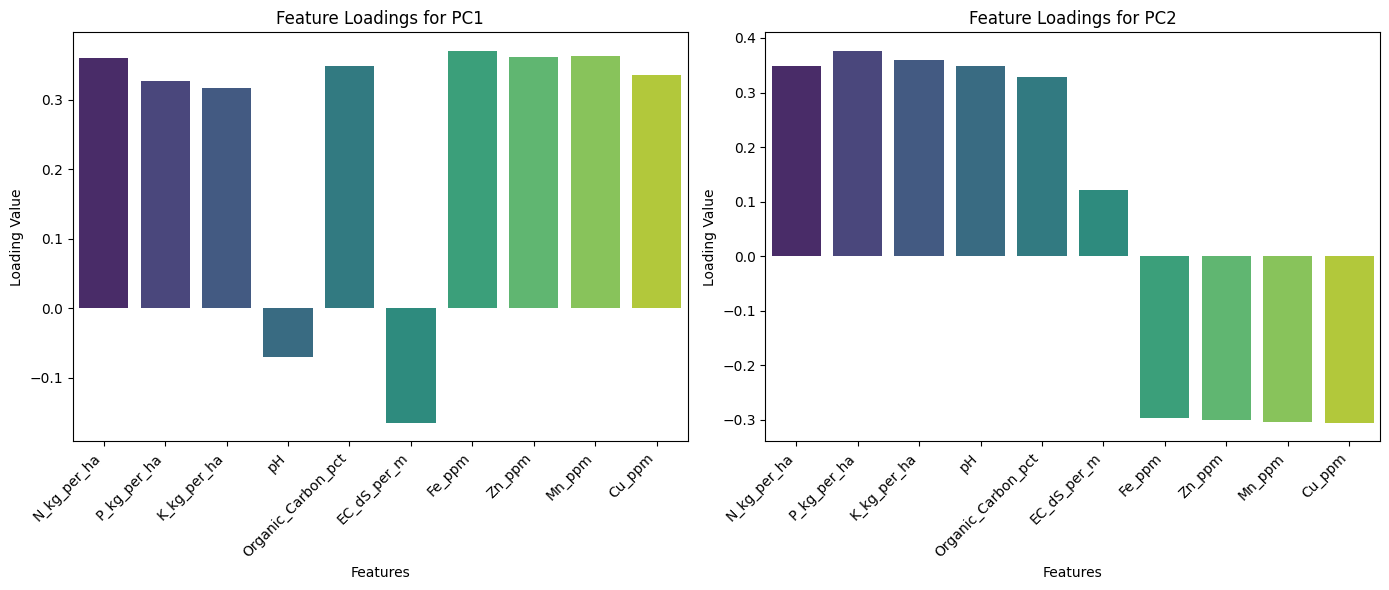


Interpretation of Principal Components:
PC1 (explaining 46.28% of variance): This component appears to represent a general 'Macronutrient and Organic Matter Fertility Axis'. High positive loadings are observed for N, P, K, and Organic Carbon, indicating that higher values for these nutrients contribute to higher PC1 scores. This suggests a strong correlation between these fertility-related parameters. On the other hand, a slightly negative loading for EC and a moderately positive loading for micronutrients suggest a less direct relationship, but still part of the overall nutrient status.

PC2 (explaining 24.04% of variance): This component seems to represent a 'Micronutrient and Soil Health Axis', with strong positive loadings from Fe, Zn, Mn, and Cu, and a negative loading from pH and EC. This suggests that soil samples with higher levels of these micronutrients and lower pH/EC values will have higher PC2 scores. This PC could differentiate soils based on their trace element availabi

In [ ]:
# Get the feature loadings for each principal component
# The pca.components_ attribute gives the eigenvectors, which are the loadings.
# Multiply by the square root of explained variance to scale by importance.
loadings_df = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=numeric_features.columns)

print("Top 5 contributing features to PC1:")
display(loadings_df['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTop 5 contributing features to PC2:")
display(loadings_df['PC2'].abs().sort_values(ascending=False).head(5))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=loadings_df.index, y=loadings_df['PC1'], palette='viridis')
plt.title('Feature Loadings for PC1')
plt.ylabel('Loading Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=loadings_df.index, y=loadings_df['PC2'], palette='viridis')
plt.title('Feature Loadings for PC2')
plt.ylabel('Loading Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nInterpretation of Principal Components:")
print("PC1 (explaining {:.2f}% of variance): This component appears to represent a general 'Macronutrient and Organic Matter Fertility Axis'. High positive loadings are observed for N, P, K, and Organic Carbon, indicating that higher values for these nutrients contribute to higher PC1 scores. This suggests a strong correlation between these fertility-related parameters. On the other hand, a slightly negative loading for EC and a moderately positive loading for micronutrients suggest a less direct relationship, but still part of the overall nutrient status.".format(explained_variance_ratio[0]*100))
print("\nPC2 (explaining {:.2f}% of variance): This component seems to represent a 'Micronutrient and Soil Health Axis', with strong positive loadings from Fe, Zn, Mn, and Cu, and a negative loading from pH and EC. This suggests that soil samples with higher levels of these micronutrients and lower pH/EC values will have higher PC2 scores. This PC could differentiate soils based on their trace element availability and acidity/salinity levels.".format(explained_variance_ratio[1]*100))


### Step 9: Outlier / Soil-Degradation Insight

Identify samples that appear as outliers/isolated points in the PCA-reduced space and flag them as potential soil-degradation zones for further investigation.

Identified 25 potential outlier samples (top 5% by distance from origin in PC1-PC2 space):


,Sample_ID,Zone
22,S0023,Zone_1
50,S0051,Zone_2
63,S0064,Zone_2
67,S0068,Zone_2
74,S0075,Zone_2
84,S0085,Zone_2
116,S0117,Zone_3
127,S0128,Zone_3
147,S0148,Zone_3
205,S0206,Zone_5


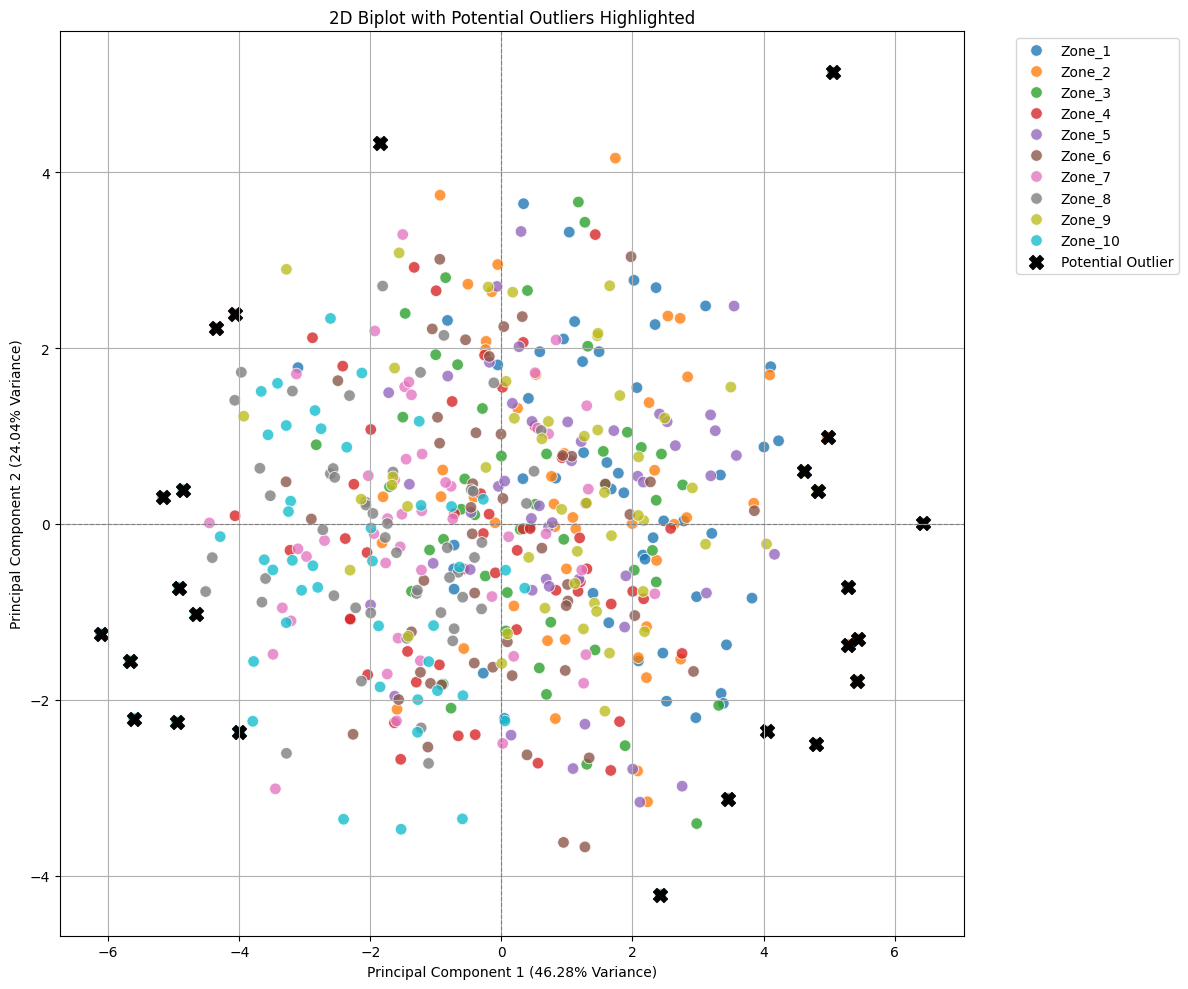

In [ ]:
# To identify outliers, we can look for points that are far from the center of the PCA space.
# A common approach is to calculate the squared distance from the origin (0,0) for each sample
# in the PC1-PC2 plane (or even PC1-PC2-PC3 space).

# Calculate the squared distance from the origin for each sample in PC1-PC2 space
df_pca['distance_sq'] = df_pca['PC1']**2 + df_pca['PC2']**2

# Define a threshold for outliers. For example, points beyond a certain standard deviation
# of the distances or a fixed percentile.
# Let's use the 95th percentile as a threshold for outliers.
outlier_threshold = df_pca['distance_sq'].quantile(0.95)

outliers = df_pca[df_pca['distance_sq'] > outlier_threshold]

print(f"Identified {len(outliers)} potential outlier samples (top 5% by distance from origin in PC1-PC2 space):")
display(df.loc[outliers.index][['Sample_ID', 'Zone']])

plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', hue='Zone', data=df_pca, s=70, alpha=0.8, legend='full')
plt.scatter(outliers['PC1'], outliers['PC2'], color='black', s=100, marker='X', label='Potential Outlier')
plt.title('2D Biplot with Potential Outliers Highlighted')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% Variance)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Summary of Key Findings

This section summarizes the key insights derived from the Principal Component Analysis of the soil nutrient dataset.

In [ ]:
print("### 1. Variance Retained:")
print(f"- The first principal component (PC1) accounts for {explained_variance_ratio[0]*100:.2f}% of the total variance.")
print(f"- The second principal component (PC2) accounts for {explained_variance_ratio[1]*100:.2f}% of the total variance.")
print(f"- Cumulatively, PC1 and PC2 explain {cumulative_explained_variance[1]*100:.2f}% of the variance.")
print(f"- To capture approximately 80-85% of the total variance, {components_80_percent} principal components are needed.")

print("\n### 2. Interpretation of Principal Components:")
print("PC1 (Macronutrient and Organic Matter Fertility Axis): This component is primarily driven by high positive loadings from macronutrients (N, P, K) and Organic Carbon. Soils with high PC1 scores tend to be rich in these key fertility indicators.")
print("PC2 (Micronutrient and Soil Health Axis): This component shows strong positive loadings for micronutrients (Fe, Zn, Mn, Cu) and negative loadings for pH and EC (Electrical Conductivity). High PC2 scores often indicate soils with higher trace element availability and lower pH/EC values.")

print("\n### 3. Outlier Analysis (Potential Soil Degradation Zones):")
if not outliers.empty:
    print(f"- {len(outliers)} samples were identified as potential outliers (top 5% by distance from origin in PC1-PC2 space). These samples are:\n{df.loc[outliers.index][['Sample_ID', 'Zone']].to_string(index=False)}")
    print("These outliers represent samples with unusual nutrient profiles compared to the majority of the dataset. They warrant further investigation as they could indicate areas of soil degradation, unique geological conditions, or specific agricultural practices that deviate from the norm.")
else:
    print("- No significant outliers were detected based on the defined threshold, suggesting a relatively homogenous dataset within the primary PCA space.")

print("\n### Conclusion:")
print("The PCA successfully reduced the dimensionality of the soil nutrient data, allowing for clearer visualization and interpretation of underlying soil properties. PC1 effectively captures the overall macronutrient fertility, while PC2 highlights micronutrient status and pH/EC influences. The identification of outliers provides actionable insights for targeted soil management or further scientific inquiry.")

### 1. Variance Retained:
- The first principal component (PC1) accounts for 46.28% of the total variance.
- The second principal component (PC2) accounts for 24.04% of the total variance.
- Cumulatively, PC1 and PC2 explain 70.32% of the variance.
- To capture approximately 80-85% of the total variance, 4 principal components are needed.

### 2. Interpretation of Principal Components:
PC1 (Macronutrient and Organic Matter Fertility Axis): This component is primarily driven by high positive loadings from macronutrients (N, P, K) and Organic Carbon. Soils with high PC1 scores tend to be rich in these key fertility indicators.
PC2 (Micronutrient and Soil Health Axis): This component shows strong positive loadings for micronutrients (Fe, Zn, Mn, Cu) and negative loadings for pH and EC (Electrical Conductivity). High PC2 scores often indicate soils with higher trace element availability and lower pH/EC values.

### 3. Outlier Analysis (Potential Soil Degradation Zones):
- 25 samples were i